# Zadanie 2 Odporność sieci na uszkodzenia





Kacper Kaszuba

In [ ]:
# import bibliotek
import networkx as nx
from networkx.algorithms.community import girvan_newman, louvain_communities, label_propagation_communities, asyn_fluidc
from networkx.algorithms.community.quality import modularity

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import pandas as pd
import numpy as np
import seaborn as sns

import random
from pprint import pprint


In [ ]:
G0 = nx.karate_club_graph()


def largest_component_stats(H):
    C = H.subgraph(max(nx.connected_components(H), key=len)).copy()
    x = [stopien for wezel, stopien in H.degree]
    return {
        'components': nx.number_connected_components(H),
        'largest_cc': C.number_of_nodes(),
        'avg_path': nx.average_shortest_path_length(C),
        'clustering': nx.average_clustering(C),
        'average_degree': np.mean(x),
        'avg_diam_comp': nx.diameter(C)
    }

def remove_by_degree(G, k):
    H = G.copy()
    nodes = [n for n, _ in sorted(H.degree, key=lambda x: x[1], reverse=True)[:k]]
    H.remove_nodes_from(nodes)
    return H, nodes

###Parametry które będziemy wybierać to:

- liczbę składowych spójnych
- rozmiar największej składowej
- średnią długość ścieżki w największej składowej
- średni clustering
- średni stopień
- średnicę największej składowej

Nie jest ich jakoś dużo i nie zwiększą diametralnie kodu a będzie dokładniej

1. Usuwamy według malejącego stopnia

In [ ]:
lista_G1 = []
for node in range(1,6):
  # usuwamy node
  G1, nodes = remove_by_degree(G0, node)
  # sprawdzamy dane
  print(f"Usunięte node to: {nodes}\n")
  G1_dict = largest_component_stats(G1)

  # print danych dla przejrzystości
  pprint(G1_dict)
  print()

  # Dodajemy dane do list aby zamienić ją potem na DF
  lista_G1.append(G1_dict)


# Zamiana całej lsity na df
G1_df = pd.DataFrame(lista_G1)
G1_df_sum = G1_df.copy()

G1_df_sum['Usunięte_węzły'] = nodes
G1_df_sum['Strategia'] = 'Usuwamy według malejącego stopnia'
G1_df_sum.index = G1_df_sum.index + 1
G1_df_sum.index.name = 'Nr node deleted'
G1_df_sum

Usunięte node to: [33]

{'average_degree': np.float64(3.696969696969697),
 'avg_diam_comp': 6,
 'avg_path': 2.596590909090909,
 'clustering': 0.39037343128252217,
 'components': 1,
 'largest_cc': 33}

Usunięte node to: [33, 0]

{'average_degree': np.float64(2.8125),
 'avg_diam_comp': 5,
 'avg_path': 2.5907692307692307,
 'clustering': 0.20127372627372625,
 'components': 3,
 'largest_cc': 26}

Usunięte node to: [33, 0, 32]

{'average_degree': np.float64(2.193548387096774),
 'avg_diam_comp': 6,
 'avg_path': 2.805263157894737,
 'clustering': 0.19285714285714287,
 'components': 8,
 'largest_cc': 20}

Usunięte node to: [33, 0, 32, 2]

{'average_degree': np.float64(1.7333333333333334),
 'avg_diam_comp': 4,
 'avg_path': 2.022222222222222,
 'clustering': 0.24285714285714283,
 'components': 10,
 'largest_cc': 10}

Usunięte node to: [33, 0, 32, 2, 1]

{'average_degree': np.float64(1.3103448275862069),
 'avg_diam_comp': 5,
 'avg_path': 2.2142857142857144,
 'clustering': 0.125,
 'components': 14,
 

,components,largest_cc,avg_path,clustering,average_degree,avg_diam_comp,Usunięte_węzły,Strategia
Nr node deleted,,,,,,,,
1,1,33,2.596591,0.390373,3.696970,6,33,Usuwamy według malejącego stopnia
2,3,26,2.590769,0.201274,2.812500,5,0,Usuwamy według malejącego stopnia
3,8,20,2.805263,0.192857,2.193548,6,32,Usuwamy według malejącego stopnia
4,10,10,2.022222,0.242857,1.733333,4,2,Usuwamy według malejącego stopnia
5,14,8,2.214286,0.125000,1.310345,5,1,Usuwamy według malejącego stopnia


2. Usuwamy według malejącego betweenness

In [ ]:
def remove_by_betweenness(G, k):
    H = G.copy()
    nodes = [n for n, _ in sorted(nx.betweenness_centrality(H).items(), key=lambda x: x[1], reverse=True)[:k]]
    H.remove_nodes_from(nodes)
    return H, nodes

In [ ]:
lista_G2 = []
for node in range(1, 6):
  # usuwamy node
  G2, nodes = remove_by_betweenness(G0, node)
  # sprawdzamy dane
  print(f"Usunięte node to: {nodes}\n")
  G2_dict = largest_component_stats(G2)

  # print danych dla przejrzystości
  pprint(G2_dict)
  print()

  # Dodajemy dane do list aby zamienić ją potem na DF
  lista_G2.append(G2_dict)


# Zamiana całej lsity na df
G2_df = pd.DataFrame(lista_G2)
G2_df_sum = G2_df.copy()

G2_df_sum['Usunięte_węzły'] = nodes
G2_df_sum['Strategia'] = 'Usuwamy według malejącego betweenness'
G2_df_sum.index = G2_df_sum.index + 1
G2_df_sum.index.name = 'Nr node deleted'

G2_df_sum

Usunięte node to: [0]

{'average_degree': np.float64(3.757575757575758),
 'avg_diam_comp': 5,
 'avg_path': 2.2792022792022792,
 'clustering': 0.45750007073536486,
 'components': 3,
 'largest_cc': 27}

Usunięte node to: [0, 33]

{'average_degree': np.float64(2.8125),
 'avg_diam_comp': 5,
 'avg_path': 2.5907692307692307,
 'clustering': 0.20127372627372625,
 'components': 3,
 'largest_cc': 26}

Usunięte node to: [0, 33, 32]

{'average_degree': np.float64(2.193548387096774),
 'avg_diam_comp': 6,
 'avg_path': 2.805263157894737,
 'clustering': 0.19285714285714287,
 'components': 8,
 'largest_cc': 20}

Usunięte node to: [0, 33, 32, 2]

{'average_degree': np.float64(1.7333333333333334),
 'avg_diam_comp': 4,
 'avg_path': 2.022222222222222,
 'clustering': 0.24285714285714283,
 'components': 10,
 'largest_cc': 10}

Usunięte node to: [0, 33, 32, 2, 31]

{'average_degree': np.float64(1.5862068965517242),
 'avg_diam_comp': 4,
 'avg_path': 2.022222222222222,
 'clustering': 0.24285714285714283,
 'comp

,components,largest_cc,avg_path,clustering,average_degree,avg_diam_comp,Usunięte_węzły,Strategia
Nr node deleted,,,,,,,,
1,3,27,2.279202,0.457500,3.757576,5,0,Usuwamy według malejącego betweenness
2,3,26,2.590769,0.201274,2.812500,5,33,Usuwamy według malejącego betweenness
3,8,20,2.805263,0.192857,2.193548,6,32,Usuwamy według malejącego betweenness
4,10,10,2.022222,0.242857,1.733333,4,2,Usuwamy według malejącego betweenness
5,11,10,2.022222,0.242857,1.586207,4,31,Usuwamy według malejącego betweenness


3. Usuwamy losowo

In [ ]:
def remove_by_random(G, k):
    H = G.copy()
    nodes = random.sample(list(H.nodes), k)
    H.remove_nodes_from(nodes)
    return H, nodes

In [ ]:
lista_G3 = []
for node in range(1, 6):
  # usuwamy node
  G3, nodes = remove_by_random(G0, node)
  # sprawdzamy dane
  print(f"Usunięte node to: {nodes}\n")
  G3_dict = largest_component_stats(G3)

  # print danych dla przejrzystości
  pprint(G3_dict)
  print()

  # Dodajemy dane do list aby zamienić ją potem na DF
  lista_G3.append(G3_dict)


# Zamiana całej lsity na df
G3_df = pd.DataFrame(lista_G3)
G3_df_sum = G3_df.copy()

G3_df_sum['Usunięte_węzły'] = nodes
G3_df_sum['Strategia'] = 'Usuwamy losowo'
G3_df_sum.index = G3_df_sum.index + 1
G3_df_sum.index.name = 'Nr node deleted'


G3_df_sum

Usunięte node to: [3]

{'average_degree': np.float64(4.363636363636363),
 'avg_diam_comp': 5,
 'avg_path': 2.4242424242424243,
 'clustering': 0.5306433960177276,
 'components': 1,
 'largest_cc': 33}

Usunięte node to: [10, 19]

{'average_degree': np.float64(4.5),
 'avg_diam_comp': 5,
 'avg_path': 2.4193548387096775,
 'clustering': 0.5934616598679099,
 'components': 1,
 'largest_cc': 32}

Usunięte node to: [18, 33, 31]

{'average_degree': np.float64(3.5483870967741935),
 'avg_diam_comp': 6,
 'avg_path': 2.713978494623656,
 'clustering': 0.39244751664106503,
 'components': 1,
 'largest_cc': 31}

Usunięte node to: [5, 23, 33, 8]

{'average_degree': np.float64(3.2666666666666666),
 'avg_diam_comp': 6,
 'avg_path': 2.6390804597701147,
 'clustering': 0.3616056166056166,
 'components': 1,
 'largest_cc': 30}

Usunięte node to: [18, 22, 19, 17, 8]

{'average_degree': np.float64(4.413793103448276),
 'avg_diam_comp': 5,
 'avg_path': 2.4113300492610836,
 'clustering': 0.5396004378763,
 'components

,components,largest_cc,avg_path,clustering,average_degree,avg_diam_comp,Usunięte_węzły,Strategia
Nr node deleted,,,,,,,,
1,1,33,2.424242,0.530643,4.363636,5,18,Usuwamy losowo
2,1,32,2.419355,0.593462,4.500000,5,22,Usuwamy losowo
3,1,31,2.713978,0.392448,3.548387,6,19,Usuwamy losowo
4,1,30,2.639080,0.361606,3.266667,6,17,Usuwamy losowo
5,1,29,2.411330,0.539600,4.413793,5,8,Usuwamy losowo


### Wizualizacja
Wykresy

In [ ]:
nazwy = ['components',
        'largest_cc',
        'avg_path',
        'clustering',
        'average_degree',
        'avg_diam_comp']

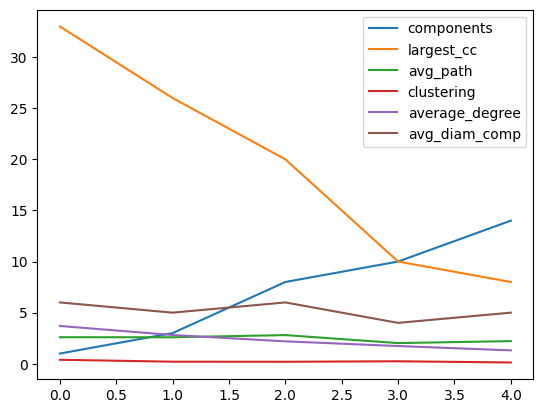

In [ ]:
plt.plot(G1_df, label=nazwy)
plt.legend()
plt.show()

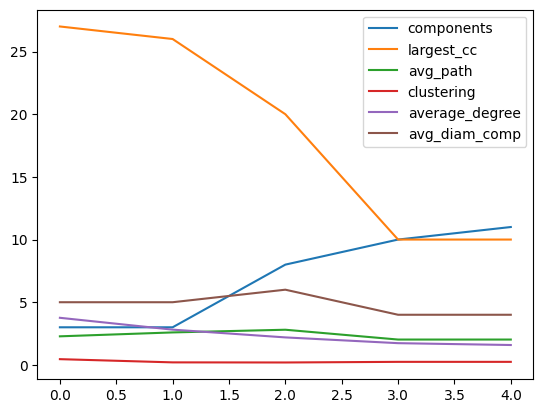

In [ ]:
plt.plot(G2_df, label=nazwy)
plt.legend()
plt.show()

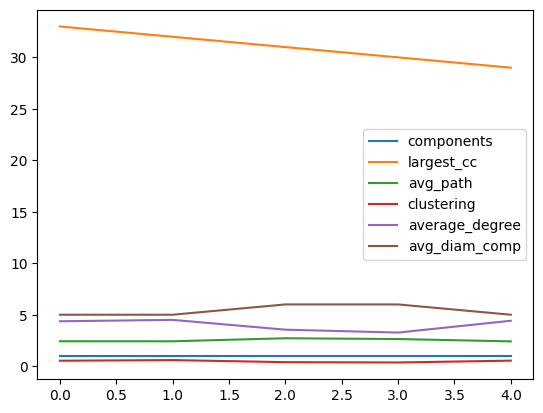

In [ ]:
plt.plot(G3_df, label=nazwy)
plt.legend()
plt.show()

Tabele


In [ ]:
Df_sumarry = pd.concat([G1_df_sum, G2_df_sum, G3_df_sum])
Df_sumarry = Df_sumarry.set_index(['Strategia', 'Usunięte_węzły'])
Df_sumarry

components  largest_cc  \
Strategia                             Usunięte_węzły                           
Usuwamy według malejącego stopnia     33                       1          33   
                                      0                        3          26   
                                      32                       8          20   
                                      2                       10          10   
                                      1                       14           8   
Usuwamy według malejącego betweenness 0                        3          27   
                                      33                       3          26   
                                      32                       8          20   
                                      2                       10          10   
                                      31                      11          10   
Usuwamy losowo                        18                       1          33   
                                      22                       1          32   
                                      19                       1          31   
                                      17                       1          30   
                                      8                        1          29   

                                                      avg_path  clustering  \
Strategia                             Usunięte_węzły                         
Usuwamy według malejącego stopnia     33              2.596591    0.390373   
                                      0               2.590769    0.201274   
                                      32              2.805263    0.192857   
                                      2               2.022222    0.242857   
                                      1               2.214286    0.125000   
Usuwamy według malejącego betweenness 0               2.279202    0.457500   
                                      33              2.590769    0.201274   
                                      32              2.805263    0.192857   
                                      2               2.022222    0.242857   
                                      31              2.022222    0.242857   
Usuwamy losowo                        18              2.424242    0.530643   
                                      22              2.419355    0.593462   
                                      19              2.713978    0.392448   
                                      17              2.639080    0.361606   
                                      8               2.411330    0.539600   

                                                      average_degree  \
Strategia                             Usunięte_węzły                   
Usuwamy według malejącego stopnia     33                    3.696970   
                                      0                     2.812500   
                                      32                    2.193548   
                                      2                     1.733333   
                                      1                     1.310345   
Usuwamy według malejącego betweenness 0                     3.757576   
                                      33                    2.812500   
                                      32                    2.193548   
                                      2                     1.733333   
                                      31                    1.586207   
Usuwamy losowo                        18                    4.363636   
                                      22                    4.500000   
                                      19                    3.548387   
                                      17                    3.266667   
                                      8                     4.413793   

                                                      avg_diam_comp  
Strategia                             Usunięte_węzły                 
U

**Notka** zrobilem Dataframe o nazwie np: G1_df dla wykresu i G1_df_sum dla tabelki aby nie kolidowały ze sobą

# Notatki i wnioski do Zadania 2

### Przyjęta strategia obliczeń:
- Wybrałem **ranking ustalony na początku**.
- Raz wyliczyłem globalny ranking dla całego klubu (dla `degree` i `betweenness`), a potem usuwałem z niego po kolei top 1, 2, 3, 4 i 5 węzłów.
- **Uzasadnienie braku przeliczania rankingu:** Nie przeliczałem miar po każdym usunięciu. Moje podejście symuluje z góry "zaplanowany atak" na bazową strukturę. Przeliczanie po każdym kroku (wersja adaptacyjna) fajnie symulowałoby powolny rozpad, ale wersja statyczna lepiej pokazuje, jak bardzo klub opiera się na swoich pierwotnych liderach.

### Najbardziej niszcząca metoda:
- Usuwanie po **największym `degree`** oraz po **największym `betweenness`**.
- W tym przypadku obie metody niszczą sieć równie szybko i drastycznie.
- Wynika to z faktu, że w Karate Club główne węzły (np. 0 i 33) to jednocześnie osoby z największą liczbą kontaktów i główne "mosty" łączące różne grupy.

### Interpretacja wyników:
1. Odp. na "Czy usuwanie węzłów o największym stopniu daje ten sam efekt co usuwanie węzłów o największym pośrednictwie?".
W tym konkretnym grafie tak. Wynika to z tego, że najpopularniejsze osoby to jednocześnie jedyne łączniki między frakcjami. W innej sieci mogłoby być inaczej (można mieć małe `degree`, a duży wpływ jako pośrednik), ale tutaj obie strategie od razu "odcinają głowę" i paraliżują klub.

2. Odp. na "Która miara najlepiej pokazuje „rozpad” sieci?".
Zdecydowanie **liczba składowych spójnych (`components`)** oraz **rozmiar największej składowej (`largest_cc`)**.
Wzrost `components` idealnie pokazuje moment, w którym sieć pęka na odizolowane "wyspy". Z kolei szybki spadek `largest_cc` obrazuje, jak kurczy się główna, działająca grupa po utracie liderów.

3. Odp. na "Czy losowe usuwanie 5 węzłów może czasem dać efekt podobny do ataku ukierunkowanego?".
Tak, ale wymaga to ogromnego "szczęścia" w losowaniu. Zazwyczaj usuwane są wtedy węzły peryferyjne, co nie psuje globalnej struktury (największa składowa niewiele maleje). Jednak jeśli algorytm wylosuje główne węzły (np. 0 i 33), efekt będzie tak samo drastyczny jak przy ataku celowanym, choć szansa na to na pierwszych 5 krokach jest bardzo mała.